In [4]:
import pandas as pd
df = pd.read_csv("C:/Users/UserHp/Desktop/projet-python/Ransomware and Goodware  File API Dataset (1).csv")
#print(df.head())
#print(df.tail())
print(df.shape)
df1 = df.drop_duplicates()
print(df1.shape)
df1.to_csv("Original_dataset.csv",index=False)

(806, 65)
(588, 65)


In [5]:
print(df1.columns)

Index(['Label', 'CopyFileA', 'CopyFileW', 'CreateDirectoryW', 'DeleteFileW',
       'DeviceIoControl', 'FindFirstFileExW', 'GetFileAttributesExW',
       'GetFileAttributesW', 'GetFileInformationByHandle',
       'GetFileInformationByHandleEx', 'GetFileSize', 'GetFileSizeEx',
       'GetFileType', 'GetFileVersionInfoExW', 'GetFileVersionInfoSizeExW',
       'GetFileVersionInfoSizeW', 'GetFileVersionInfoW', 'GetShortPathNameW',
       'GetSystemDirectoryA', 'GetSystemDirectoryW', 'GetSystemTimeAsFileTime',
       'GetSystemWindowsDirectoryA', 'GetSystemWindowsDirectoryW',
       'GetTempPathW', 'GetVolumeNameForVolumeMountPointW',
       'GetVolumePathNamesForVolumeNameW', 'GetVolumePathNameW',
       'InternetReadFile', 'MoveFileWithProgressW', 'NtCreateFile',
       'NtDeviceIoControlFile', 'NtOpenDirectoryObject', 'NtOpenFile',
       'NtQueryAttributesFile', 'NtQueryDirectoryFile',
       'NtQueryInformationFile', 'NtReadFile', 'NtSetInformationFile',
       'NtWriteFile', 'RemoveDi

In [6]:
print(df1['Label'])

0        Goodware
1        Goodware
3        Goodware
4        Goodware
5        Goodware
          ...    
789    Ransomware
793    Ransomware
799    Ransomware
801    Ransomware
805    Ransomware
Name: Label, Length: 588, dtype: object


In [7]:
# Conversion des étiquettes catégorielles en valeurs binaires
df1['LabelNv'] = (df1['Label'] == 'Ransomware').astype(int)
df1 = df1.drop('Label', axis=1)
counts = df1['LabelNv'].value_counts()
percent = df1['LabelNv'].value_counts(normalize=True) * 100
resume = pd.concat([counts, percent], axis=1)
resume.columns = ['Nombre', 'Pourcentage (%)']

print(resume)

         Nombre  Pourcentage (%)
LabelNv                         
0           315        53.571429
1           273        46.428571


C:\Users\UserHp\AppData\Local\Temp\ipykernel_13836\4209434743.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['LabelNv'] = (df1['Label'] == 'Ransomware').astype(int)


In [8]:
file_ops_existants = [
    'CopyFileA', 'CopyFileW',
    'DeleteFileW', 'MoveFileWithProgressW',
    'NtCreateFile', 'NtReadFile', 'NtWriteFile',
    'NtOpenFile', 'NtSetInformationFile',
    'SetEndOfFile', 'SetFilePointer', 'SetFilePointerEx',
    'SetFileTime', 'SetFileAttributesW',
    'SetFileInformationByHandle',
    'SUMMARY_FILE_COPIED', 'SUMMARY_FILE_CREATED',
    'SUMMARY_FILE_DELETED', 'SUMMARY_FILE_MOVED',
    'SUMMARY_FILE_OPENED', 'SUMMARY_FILE_READ',
    'SUMMARY_FILE_WRITTEN', 'SUMMARY_FILE_FAILED',
    'SUMMARY_FILE_EXISTS', 'SUMMARY_FILE_RECREATED'
]
df1['activite_fichier']    = df1[file_ops_existants].sum(axis=1)
print(df1['activite_fichier'])

0          6
1       1747
3       2896
4        788
5       1178
       ...  
789      133
793     1210
799      116
801    20020
805     1024
Name: activite_fichier, Length: 588, dtype: int64


In [9]:
network_ops_existants = [
    'InternetReadFile',
    'URLDownloadToFileW'
]
df1['activite_reseau'] = df1[network_ops_existants].sum(axis=1)
print(df1['activite_reseau'] )

0      0
1      0
3      0
4      0
5      0
      ..
789    0
793    0
799    0
801    0
805    0
Name: activite_reseau, Length: 588, dtype: int64


In [10]:
dir_ops_existants = [
    'CreateDirectoryW',
    'RemoveDirectoryA', 'RemoveDirectoryW',
    'FindFirstFileExW', 'FindFirstFileExA',
    'NtQueryDirectoryFile',
    'NtOpenDirectoryObject',
    'SUMMARY_DIRECTORY_CREATED',
    'SUMMARY_DIRECTORY_ENUMERATED',
    'SUMMARY_DIRECTORY_REMOVED'
]
df1['activite_repertoire'] = df1[dir_ops_existants].sum(axis=1)
print(df1['activite_repertoire'] )

0        0
1      187
3      369
4      253
5      128
      ... 
789     68
793    375
799      0
801     10
805      8
Name: activite_repertoire, Length: 588, dtype: int64


In [11]:
system_ops_existants = [
    'DeviceIoControl','NtDeviceIoControlFile','NtQueryAttributesFile',
    'NtQueryInformationFile','NtQueryFullAttributesFile','GetFileAttributesW',
    'GetFileAttributesExW','GetFileInformationByHandle','GetFileInformationByHandleEx',
    'GetFileSize','GetFileSizeEx','GetFileType',
    'GetFileVersionInfoW','GetFileVersionInfoSizeW','GetFileVersionInfoExW',
    'GetFileVersionInfoSizeExW','GetShortPathNameW','GetSystemDirectoryA',
    'GetSystemDirectoryW','GetSystemWindowsDirectoryA','GetSystemWindowsDirectoryW',
    'GetTempPathW','GetVolumePathNameW','GetVolumeNameForVolumeMountPointW',
    'GetVolumePathNamesForVolumeNameW','GetSystemTimeAsFileTime','SearchPathW']
df1['activite_systeme'] = df1[system_ops_existants].sum(axis=1)
print(df1['activite_systeme'])

0         4
1       646
3      2141
4       502
5       436
       ... 
789     160
793    1049
799     168
801     308
805      54
Name: activite_systeme, Length: 588, dtype: int64


In [12]:
df1['chiffre_fichiers'] = (
    (df1['SetEndOfFile'] > 0) & (df1['NtWriteFile'] > 0)).astype(int)

print(df1['chiffre_fichiers'])

0      0
1      1
3      1
4      0
5      1
      ..
789    0
793    0
799    0
801    0
805    0
Name: chiffre_fichiers, Length: 588, dtype: int64


In [13]:
df1['presence_reseau'] = (df1['activite_reseau'] > 0).astype(int)
print(df1['presence_reseau'])



0      0
1      0
3      0
4      0
5      0
      ..
789    0
793    0
799    0
801    0
805    0
Name: presence_reseau, Length: 588, dtype: int64


In [14]:
df1['enumere_repertoires'] = (df1['activite_repertoire'] > 5).astype(int)
print(df1['enumere_repertoires'])



0      0
1      1
3      1
4      1
5      1
      ..
789    1
793    1
799    0
801    1
805    1
Name: enumere_repertoires, Length: 588, dtype: int64


In [15]:
df1['modifie_fichiers'] = (df1['activite_fichier'] > 10).astype(int)
print(df1['modifie_fichiers'])



0      0
1      1
3      1
4      1
5      1
      ..
789    1
793    1
799    1
801    1
805    1
Name: modifie_fichiers, Length: 588, dtype: int64


In [16]:
df1['ops_systeme_intensives'] = (df1['activite_systeme'] > 20).astype(int)
print(df1['ops_systeme_intensives'])



0      0
1      1
3      1
4      1
5      1
      ..
789    1
793    1
799    1
801    1
805    1
Name: ops_systeme_intensives, Length: 588, dtype: int64


In [17]:
df1['score_suspicion'] = df1[[
    'chiffre_fichiers', 'presence_reseau', 'enumere_repertoires',
    'modifie_fichiers', 'ops_systeme_intensives'
]].sum(axis=1)
print(df1['score_suspicion'])


0      0
1      4
3      4
4      3
5      4
      ..
789    3
793    3
799    2
801    3
805    3
Name: score_suspicion, Length: 588, dtype: int64


In [18]:
table = df1.groupby(['score_suspicion', 'LabelNv']).size().unstack(fill_value=0)

table.columns = ['Goodware (nb)', 'Ransomware (nb)']

print(table)

                 Goodware (nb)  Ransomware (nb)
score_suspicion                                
0                           42               39
1                           13               31
2                           14               28
3                          107              129
4                          134               32
5                            5               14


In [19]:
df1['ratio_ecriture_lecture'] = df1['NtWriteFile'] / (df['NtReadFile'] + 1)
print(df1['ratio_ecriture_lecture'])

0      0.000000
1      0.849741
3      0.756466
4      0.213287
5      0.586667
         ...   
789    0.000000
793    6.526316
799    0.000000
801    0.333333
805    0.000000
Name: ratio_ecriture_lecture, Length: 588, dtype: float64


In [17]:
df1['ratio_fichier_systeme'] = df1['activite_fichier'] / (df1['activite_systeme'] + 1)
print(df1['ratio_fichier_systeme'])

0       1.200000
1       2.700155
3       1.352007
4       1.566600
5       2.695652
         ...    
789     0.826087
793     1.152381
799     0.686391
801    64.789644
805    18.618182
Name: ratio_fichier_systeme, Length: 588, dtype: float64


In [20]:
df1['ratio_enumeration_ouverture'] = (df1['FindFirstFileExW'] + df1['FindFirstFileExA']) / (df1['NtOpenFile'] + 1)
print(df1['ratio_enumeration_ouverture'])


0       0.000000
1       0.093617
3       0.062112
4       0.523810
5       0.202703
         ...    
789    17.000000
793     0.000000
799     0.000000
801     5.000000
805     0.000000
Name: ratio_enumeration_ouverture, Length: 588, dtype: float64


In [ ]:
import numpy as np


df_log = df1.copy()


bool_cols = ['chiffre_fichiers', 'presence_reseau', 'enumere_repertoires',
             'modifie_fichiers', 'ops_systeme_intensives', 'Sample_Type']


for colonne in df_log.columns:
    if colonne not in bool_cols:
        if df_log[colonne].dtype in ['int64', 'float64'] and \
           not (df_log[colonne].isin([0, 1]).all()):
            df_log[colonne] = np.log1p(df_log[colonne])



In [22]:
df1=df_log
print(df1)

     CopyFileA  CopyFileW  CreateDirectoryW  DeleteFileW  DeviceIoControl  \
0          0.0   0.000000          0.000000     0.000000         0.000000   
1          0.0   2.079442          2.302585     2.772589         0.693147   
3          0.0   2.079442          2.995732     3.135494         3.178054   
4          0.0   0.000000          2.708050     0.000000         0.693147   
5          0.0   0.000000          3.784190     0.000000         0.000000   
..         ...        ...               ...          ...              ...   
789        0.0   0.000000          0.000000     0.000000         0.000000   
793        0.0   0.000000          0.000000     2.197225         1.098612   
799        0.0   0.000000          0.000000     3.912023         0.000000   
801        0.0   0.000000          0.000000     9.903588         0.000000   
805        0.0   0.000000          0.000000     0.000000         0.000000   

     FindFirstFileExW  GetFileAttributesExW  GetFileAttributesW  \
0       

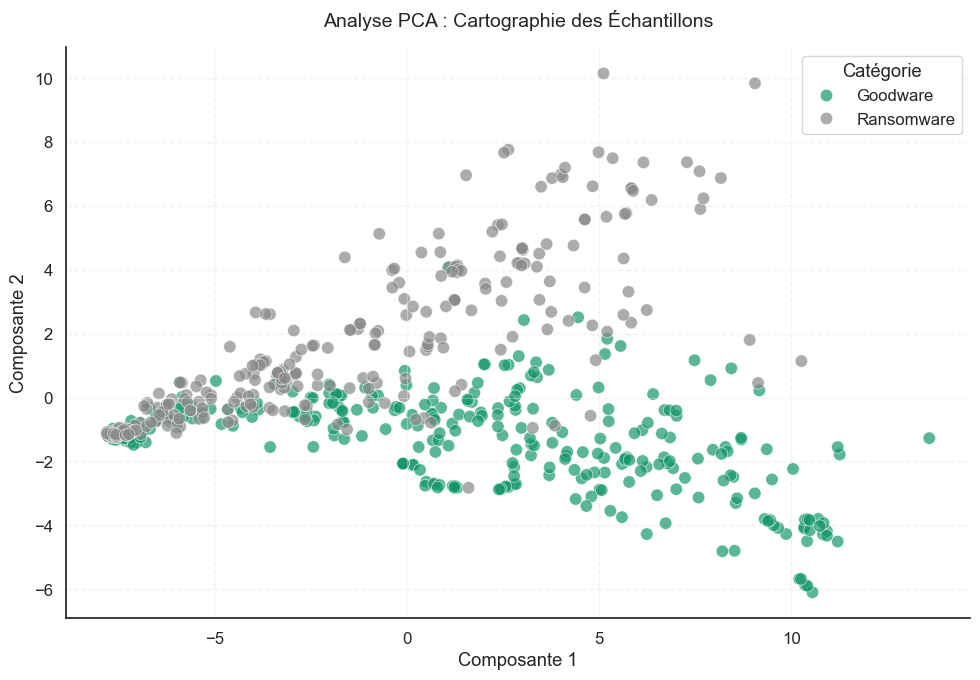

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df1.drop('LabelNv', axis=1)
y = df1['LabelNv']
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_plot['LabelNv'] = y.map({0: 'Goodware', 1: 'Ransomware'}).values

plt.figure(figsize=(10, 7))
sns.set_style("white") 


palette_chic = {"Goodware": "#15976C", "Ransomware": "#878A86"}

sns.scatterplot(
    data=df_plot, 
    x='PC1', 
    y='PC2', 
    hue='LabelNv', 
    palette=palette_chic,
    alpha=0.7,
    s=80,
    edgecolor='w', 
    linewidth=0.5
)

plt.title('Analyse PCA : Cartographie des Échantillons', fontsize=14, pad=15)
plt.xlabel('Composante 1')
plt.ylabel('Composante 2')


plt.axhline(0, color='white', linewidth=0.5, alpha=0.5)
plt.axvline(0, color='white', linewidth=0.5, alpha=0.5)

# Légende avec étiquette
plt.legend(title='Catégorie', frameon=True, loc='best')

sns.despine(left=False, bottom=False) # Réactive les bordures des axes
plt.grid(axis='both', color='#f0f0f0', linestyle='--')

plt.tight_layout()
plt.show()

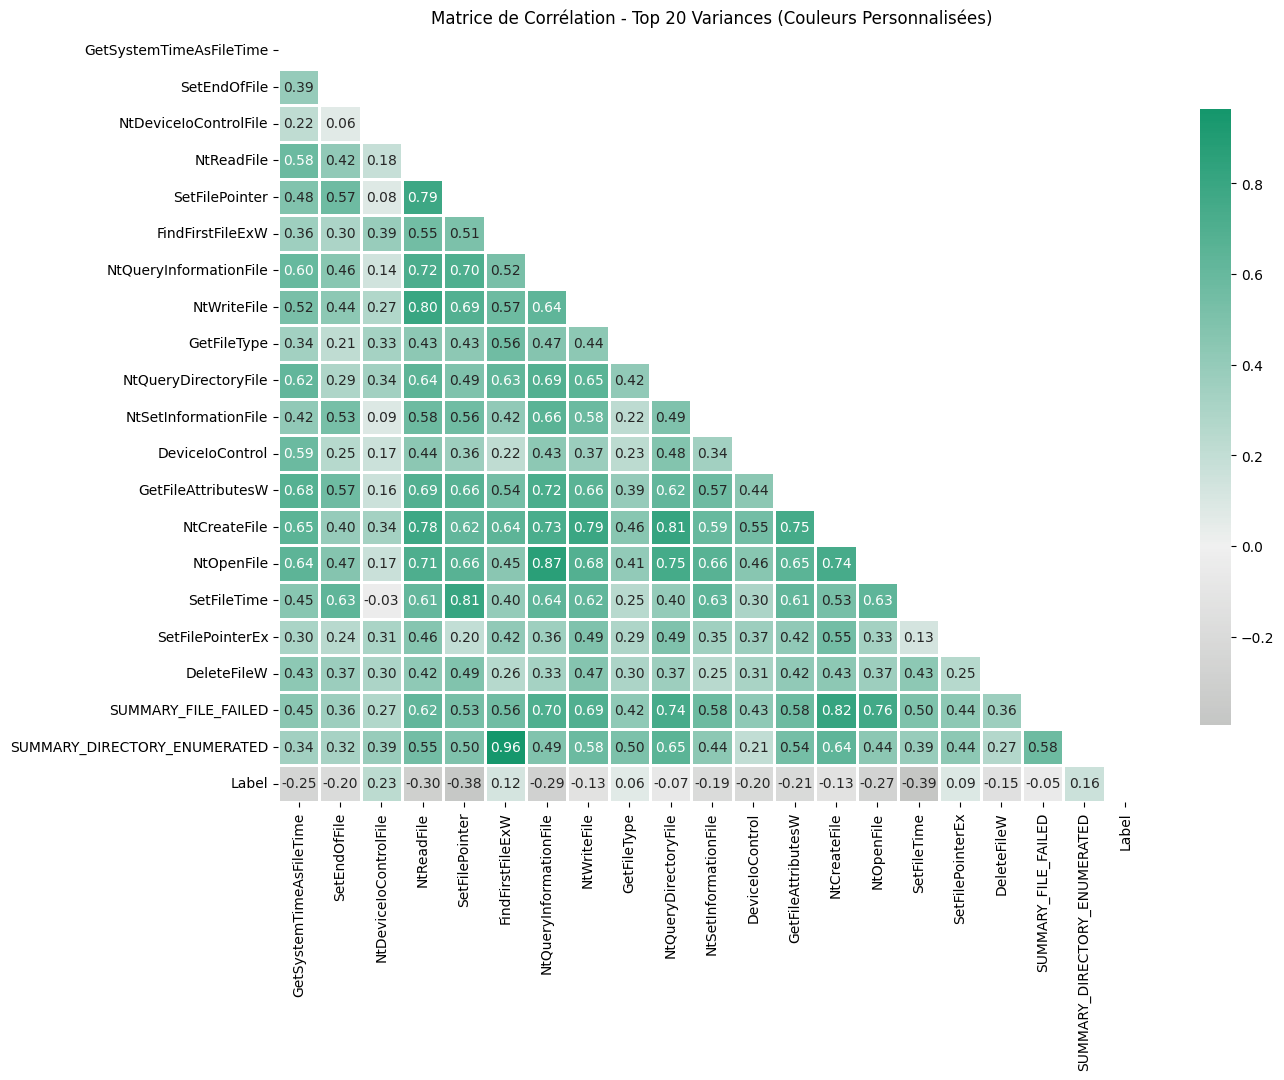

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

"C:/Users/UserHp/Desktop/projet-python/Original_dataset.csv"
df = pd.read_csv()
df['Label'] = df['Label'].map({'Goodware': 0, 'Ransomware': 1})


features_df = df.drop(columns=['Label'])
top_variance_cols = features_df.var().sort_values(ascending=False).head(20).index
df_filtered = df[list(top_variance_cols) + ['Label']]


df_log = np.log1p(df_filtered)


corr_matrix = df_log.corr()


custom_colors = ["#878A86", "#f0f0f0", "#15976C"]
my_cmap = LinearSegmentedColormap.from_list("custom_ransomware", custom_colors)


mask = np.triu(np.ones_like(corr_matrix, dtype=bool))


plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap=my_cmap,      
            center=0,          
            linewidths=0.8,
            cbar_kws={"shrink": .8})

plt.title('Matrice de Corrélation - Top 20 Variances (Couleurs Personnalisées)')
plt.show()

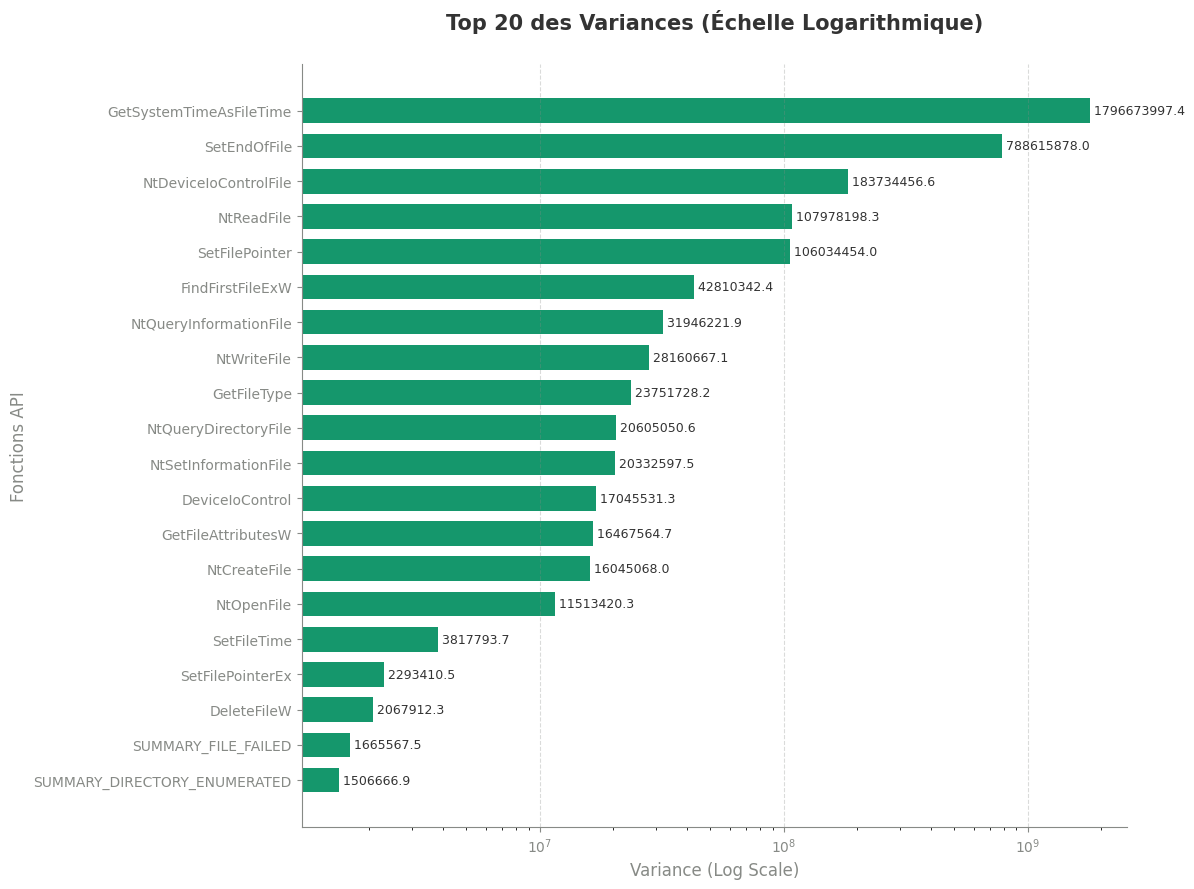

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("C:/Users/UserHp/Desktop/projet-python/Original_dataset.csv")
features_df = df.drop(columns=['Label'])


variances = features_df.var().sort_values(ascending=False).head(20)


plt.figure(figsize=(12, 9), facecolor='white')
ax = plt.gca()


plt.xscale('log') 

bars = plt.barh(variances.index[::-1], variances.values[::-1], 
                color='#15976C',      
              
                height=0.7)


plt.title('Top 20 des Variances (Échelle Logarithmique)', 
          fontsize=15, pad=25, color='#333333', fontweight='bold')
plt.xlabel('Variance (Log Scale)', fontsize=12, color='#878A86')
plt.ylabel('Fonctions API', fontsize=12, color='#878A86')


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#878A86')
ax.spines['left'].set_color('#878A86')
ax.tick_params(axis='both', colors='#878A86', labelsize=10)


plt.grid(axis='x', linestyle='--', alpha=0.3, color='#878A86')


for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, 
             f' {width:.1f}', 
             va='center', fontsize=9, color='#333333')

plt.tight_layout()
plt.show()

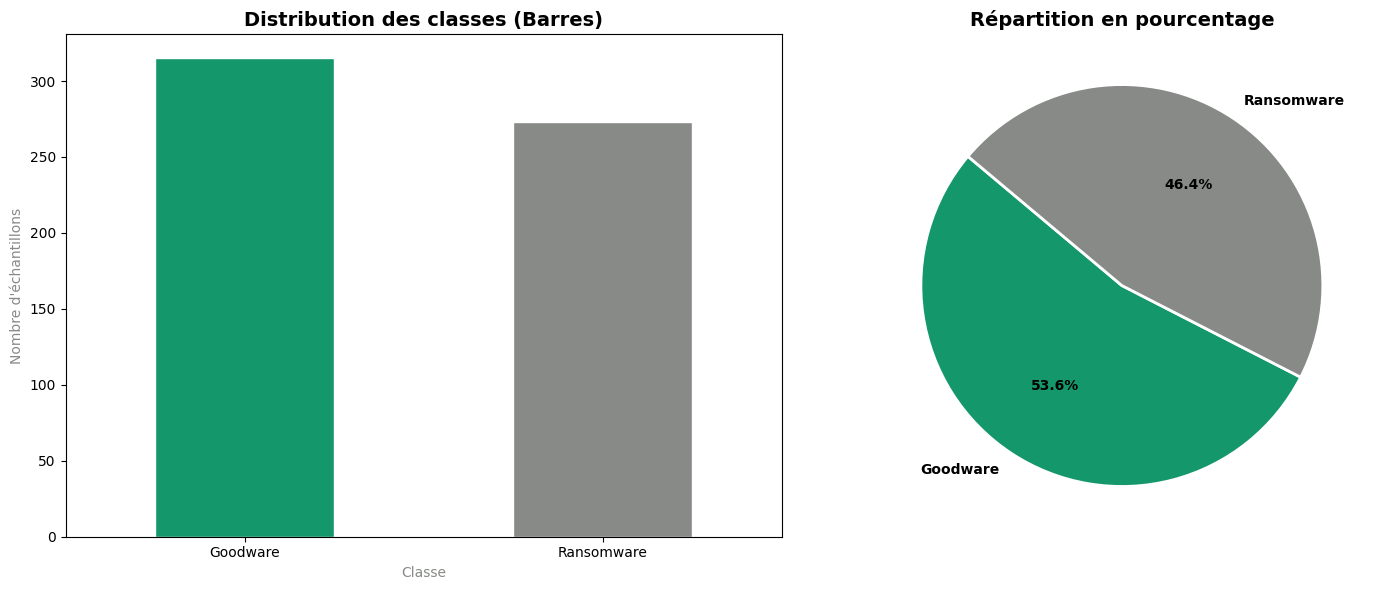

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("C:/Users/UserHp/Desktop/projet-python/Original_dataset.csv") 


counts = df['Label'].value_counts()
colors = ['#15976C', '#878A86'] 


plt.figure(figsize=(15, 6))


plt.subplot(1, 2, 1)
counts.plot(kind='bar', color=colors, edgecolor='white')
plt.title("Distribution des classes (Barres)", fontsize=14, fontweight='bold')
plt.xlabel("Classe", color='#878A86')
plt.ylabel("Nombre d'échantillons", color='#878A86')
plt.xticks(rotation=0) 


plt.subplot(1, 2, 2)
plt.pie(counts, 
        labels=counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        textprops={'fontweight': 'bold'})
plt.title("Répartition en pourcentage", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
from sklearn.model_selection import train_test_split



X = df1.drop('LabelNv', axis=1)
y = df1['LabelNv']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Taille du Train : {X_train.shape[0]} lignes")
print(f"Taille du Test  : {X_test.shape[0]} lignes")
X_train.to_csv("data_train.csv",index=False)
y_train.to_csv("data_label_train.csv",index=False)
X_test.to_csv("data_test.csv",index=False)
y_test.to_csv("data_label_test.csv",index=False)


Taille du Train : 470 lignes
Taille du Test  : 118 lignes


In [24]:
import pandas as pd
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer

df = pd.read_csv("C:/Users/UserHp/Desktop/projet-python/data_train.csv")
y_train = pd.read_csv("C:/Users/UserHp/Desktop/projet-python/data_label_train.csv")
df_train = X_train.copy()
df_train["LabelNv"] = y_train.values


metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_train)

model = CTGANSynthesizer(metadata)

model.fit(df_train)

synthetic_data = model.sample(1400)
print(synthetic_data)
print(synthetic_data.shape)

df_train_aug = pd.concat([df_train, synthetic_data], ignore_index=True)
X_train_aug = df_train_aug.drop("LabelNv", axis=1)
y_train_aug = df_train_aug["LabelNv"]
synthetic_data.to_csv("train_ctgan.csv", index=False)


c:\Users\UserHp\AppData\Local\Programs\Python\Python310\lib\site-packages\sdv\single_table\base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
c:\Users\UserHp\AppData\Local\Programs\Python\Python310\lib\site-packages\sdv\single_table\base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


      CopyFileA  CopyFileW  CreateDirectoryW  DeleteFileW  DeviceIoControl  \
0      0.000000   0.000000          3.580766     0.000000         0.335018   
1      0.020801   2.593591          4.441909     0.000000         0.000000   
2      0.000000   0.533350          0.342961     0.237512         0.304864   
3      0.000000   0.318021          0.316659     0.000000         0.000000   
4      0.000000   1.972681          3.060110     0.000000         2.456402   
...         ...        ...               ...          ...              ...   
1395   0.000000   0.000000          0.197350     0.000000         0.280502   
1396   0.037540   0.022841          0.362564     0.000000         0.040460   
1397   0.002949   0.000000          5.052706     0.000000         0.236543   
1398   0.035354   0.000000          3.191813     0.000000         1.356517   
1399   0.009298   0.000000          3.466219     0.770985         0.363739   

      FindFirstFileExW  GetFileAttributesExW  GetFileAttributes

In [41]:
import pandas as pd
from sdv.metadata import SingleTableMetadata, Metadata
from sdv.single_table import TVAESynthesizer

df = pd.read_csv("C:/Users/UserHp/Desktop/projet-python/data_train.csv")

y_train = pd.read_csv("C:/Users/UserHp/Desktop/projet-python/data_label_train.csv")

df["LabelNv"] = y_train.values
metadata = Metadata.detect_from_dataframe(df)
model = TVAESynthesizer(metadata)
model.fit(df)

synthetic_data = model.sample(1400)

df_train_aug = pd.concat([df, synthetic_data], ignore_index=True)

X = df_train_aug.drop("LabelNv", axis=1)
y = df_train_aug["LabelNv"]

synthetic_data.to_csv("train_tvae.csv", index=False)



c:\Users\UserHp\AppData\Local\Programs\Python\Python310\lib\site-packages\sdv\single_table\base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


KeyboardInterrupt: 

In [26]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import layers, Model


df = pd.read_csv("data_train.csv")  # uniquement features X

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df)

noise_factor = 0.2
X_noisy = X_scaled + noise_factor * np.random.normal(size=X_scaled.shape)
X_noisy = np.clip(X_noisy, 0., 1.)

input_dim = X_scaled.shape[1]

input_layer = layers.Input(shape=(input_dim,))

encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='relu')(encoded)

decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(
    X_noisy,
    X_scaled,
    epochs=50,
    batch_size=32,
    shuffle=True,
    validation_split=0.1
)

X_generated = autoencoder.predict(X_noisy)

X_generated = scaler.inverse_transform(X_generated)

df_generated = pd.DataFrame(X_generated, columns=df.columns)

df_augmented = pd.concat([df, df_generated], ignore_index=True)

df_augmented.to_csv("train_tdae.csv", index=False)



c:\Users\UserHp\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.1662 - val_loss: 0.1260
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1264 - val_loss: 0.0875
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0824 - val_loss: 0.0773
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0664 - val_loss: 0.0696
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0615 - val_loss: 0.0664
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0582 - val_loss: 0.0620
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0542 - val_loss: 0.0576
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0483 - val_loss: 0.0498
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0420 - val_loss: 0.0434
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0363 - val_loss: 0.0397
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0323 - val_loss: 0.0357
Epoch 12/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0293 - val_

### Modèle Random Forest

#### dataset original

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import recall_score, f1_score, precision_score,accuracy_score

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(y_pred_rf)

y_proba = rf.predict_proba(X_test)[:, 1]

#print(classification_report(y_test, y_pred))

recall = recall_score(y_test, y_pred_rf, average='macro')*100
precision = precision_score(y_test, y_pred_rf, average='macro')*100
f1 = f1_score(y_test, y_pred_rf, average='macro')*100
accuracy = accuracy_score(y_test, y_pred_rf)*100
print("accuracy",round(accuracy,2),"%")
print("Recall :", round(recall,2),"%")
print("Precision :", round(precision,2),"%")
print("F1-score :", round(f1,2),"%")
auc = roc_auc_score(y_test, y_proba)
print("AUC-ROC :", round(auc,4))

c:\Users\UserHp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[0 0 0 0 1 1 0 1 0 0 1 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 1 1 1 0
 0 1 0 1 0 1 1 0 1 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1 0 1 1 0 0 0 0 1 1 1 0 0 0
 0 1 1 0 1 1 0 1 1 0 1 0 0 1 1 0 1 0 1 1 0 0 1 1 1 1 0 0 1 1 0 0 1 0 0 1 1
 0 0 1 0 1 1 0]
accuracy 87.29 %
Recall : 87.17 %
Precision : 87.27 %
F1-score : 87.21 %
AUC-ROC : 0.9613


#### dataset_aug_ctgan

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_aug, y_train_aug)
y_pred_rf = rf.predict(X_test)
print(y_pred_rf)

y_proba = rf.predict_proba(X_test)[:, 1]



recall = recall_score(y_test, y_pred_rf, average='macro')*100
precision = precision_score(y_test, y_pred_rf, average='macro')*100
f1 = f1_score(y_test, y_pred_rf, average='macro')*100
accuracy = accuracy_score(y_test, y_pred_rf)*100
print("accuracy",round(accuracy,2),"%")
print("Recall :", round(recall,2),"%")
print("Precision :", round(precision,2),"%")
print("F1-score :", round(f1,2),"%")
auc = roc_auc_score(y_test, y_proba)
print("AUC-ROC :", round(auc,4))

[0 0 0 0 1 1 0 1 0 0 1 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 1 1 0
 0 1 0 1 0 1 1 0 1 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1 0 1 1 0 0 0 0 1 1 1 0 0 0
 0 1 0 0 1 1 1 1 1 0 1 0 0 1 1 0 1 0 1 1 0 0 1 1 1 1 0 0 1 1 0 0 1 0 0 1 1
 0 0 1 0 1 1 0]
accuracy 89.83 %
Recall : 89.67 %
Precision : 89.9 %
F1-score : 89.76 %
AUC-ROC : 0.962


### dataset_aug_tvae

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X, y)
y_pred_rf = rf.predict(X_test)
print(y_pred_rf)

y_proba = rf.predict_proba(X_test)[:, 1]



recall = recall_score(y_test, y_pred_rf, average='macro')*100
precision = precision_score(y_test, y_pred_rf, average='macro')*100
f1 = f1_score(y_test, y_pred_rf, average='macro')*100
accuracy = accuracy_score(y_test, y_pred_rf)*100
print("accuracy",round(accuracy,2),"%")
print("Recall :", round(recall,2),"%")
print("Precision :", round(precision,2),"%")
print("F1-score :", round(f1,2),"%")
auc = roc_auc_score(y_test, y_proba)
print("AUC-ROC :", round(auc,4))

[0 0 0 0 1 1 0 1 0 0 1 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 1 1 0
 0 1 0 1 0 1 1 0 1 0 1 0 0 0 1 1 1 0 0 1 1 0 0 1 0 1 1 0 0 0 0 1 1 1 0 0 0
 0 1 1 0 1 1 1 1 1 0 1 0 0 1 1 0 1 0 1 1 0 0 1 1 1 1 0 1 1 1 1 0 1 0 0 1 1
 0 0 1 0 1 1 0]
accuracy 89.83 %
Recall : 89.9 %
Precision : 89.76 %
F1-score : 89.8 %
AUC-ROC : 0.9661


### dataset_aug_tdae

In [30]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

X_train = pd.read_csv("data_train.csv")
y_train = pd.read_csv("data_label_train.csv").values.ravel()

X_aug = pd.read_csv("train_tdae.csv")


y_aug = np.hstack((y_train, y_train))

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_aug, y_aug)

y_pred_rf = rf.predict(X_test)

y_proba = rf.predict_proba(X_test)[:, 1]
print(y_pred_rf)

recall = recall_score(y_test, y_pred_rf, average='macro')*100
precision = precision_score(y_test, y_pred_rf, average='macro')*100
f1 = f1_score(y_test, y_pred_rf, average='macro')*100
accuracy = accuracy_score(y_test, y_pred_rf)*100
print("accuracy",round(accuracy,2),"%")
print("Recall :", round(recall,2),"%")
print("Precision :", round(precision,2),"%")
print("F1-score :", round(f1,2),"%")
auc = roc_auc_score(y_test, y_proba)
print("AUC-ROC :", round(auc,4))

[0 0 0 0 1 1 0 1 0 0 1 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 1 1 0
 0 1 0 1 0 1 1 0 1 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 1 1 0 0 0
 0 1 1 0 1 1 0 1 1 0 1 0 0 1 1 0 1 0 1 1 0 0 1 1 1 1 0 0 1 1 0 0 1 0 0 1 1
 0 0 1 0 1 1 0]
accuracy 88.98 %
Recall : 88.76 %
Precision : 89.13 %
F1-score : 88.89 %
AUC-ROC : 0.9651


### Modèle XGBoost

#### dataset original

In [32]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]
print(y_pred)
recall = recall_score(y_test, y_pred, average='macro')*100
precision = precision_score(y_test, y_pred, average='macro')*100
f1 = f1_score(y_test, y_pred, average='macro')*100
accuracy = accuracy_score(y_test, y_pred)*100
print("accuracy",round(accuracy,2),"%")
print("Recall :", round(recall,2),"%")
print("Precision :", round(precision,2),"%")
print("F1-score :", round(f1,2),"%")
auc = roc_auc_score(y_test, y_proba)
print("AUC-ROC :", round(auc,4))

[0 0 0 0 1 1 0 1 0 0 1 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 1 1 0
 0 1 0 1 0 0 1 0 1 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1 0 1 1 0 0 0 0 1 1 1 0 0 0
 0 1 1 0 1 1 0 1 1 0 1 0 0 1 1 0 0 0 1 1 0 0 1 1 1 1 0 0 1 1 0 0 1 0 0 1 1
 0 0 1 0 1 1 0]
accuracy 88.14 %
Recall : 87.85 %
Precision : 88.38 %
F1-score : 88.01 %
AUC-ROC : 0.9619


#### dataset_aug_ctgan

In [33]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train_aug, y_train_aug)

y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]
print(y_pred)

recall = recall_score(y_test, y_pred, average='macro')*100
precision = precision_score(y_test, y_pred, average='macro')*100
f1 = f1_score(y_test, y_pred, average='macro')*100
accuracy = accuracy_score(y_test, y_pred)*100
print("accuracy",round(accuracy,2),"%")
print("Recall :", round(recall,2),"%")
print("Precision :", round(precision,2),"%")
print("F1-score :", round(f1,2),"%")
auc = roc_auc_score(y_test, y_proba)
print("AUC-ROC :", round(auc,4))

[0 1 0 0 1 1 0 1 0 0 1 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 1 1 0
 0 1 0 1 0 1 1 0 1 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1 0 1 1 0 0 0 0 1 1 1 0 0 0
 1 1 0 0 1 1 1 1 1 0 1 0 0 0 1 0 0 0 1 1 0 0 1 1 1 1 0 0 1 1 0 0 1 0 0 1 1
 0 0 1 0 1 1 0]
accuracy 91.53 %
Recall : 91.37 %
Precision : 91.61 %
F1-score : 91.46 %
AUC-ROC : 0.9711


#### dataset_aug_tvae

In [34]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X, y)

y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]
print(y_pred)

recall = recall_score(y_test, y_pred, average='macro')*100
precision = precision_score(y_test, y_pred, average='macro')*100
f1 = f1_score(y_test, y_pred, average='macro')*100
accuracy = accuracy_score(y_test, y_pred)*100
print("accuracy",round(accuracy,2),"%")
print("Recall :", round(recall,2),"%")
print("Precision :", round(precision,2),"%")
print("F1-score :", round(f1,2),"%")
auc = roc_auc_score(y_test, y_proba)
print("AUC-ROC :", round(auc,4))

[0 0 0 0 1 1 0 1 0 0 1 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 1 1 1 0
 0 1 0 1 0 1 1 0 1 0 1 0 0 0 1 1 1 0 0 1 1 0 0 1 0 1 1 0 0 0 0 0 1 1 0 0 0
 0 1 1 0 1 1 1 1 1 0 1 0 0 1 1 0 0 0 1 1 0 0 1 1 1 1 0 1 1 1 1 0 1 0 0 1 1
 0 0 1 0 1 1 0]
accuracy 90.68 %
Recall : 90.69 %
Precision : 90.61 %
F1-score : 90.65 %
AUC-ROC : 0.9677


#### dataset_aug_tdae

In [35]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_aug, y_aug)

y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]
print(y_pred)

recall = recall_score(y_test, y_pred, average='macro')*100
precision = precision_score(y_test, y_pred, average='macro')*100
f1 = f1_score(y_test, y_pred, average='macro')*100
accuracy = accuracy_score(y_test, y_pred)*100
print("accuracy",round(accuracy,2),"%")
print("Recall :", round(recall,2),"%")
print("Precision :", round(precision,2),"%")
print("F1-score :", round(f1,2),"%")
auc = roc_auc_score(y_test, y_proba)
print("AUC-ROC :", round(auc,4))

[0 0 0 0 1 1 0 1 0 0 1 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 1 1 0
 0 1 0 1 0 0 1 0 1 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 1 1 0 0 0
 0 0 1 0 1 1 1 1 1 0 1 0 0 1 1 0 1 0 1 1 0 0 1 1 1 1 0 1 1 1 0 0 1 0 0 1 1
 0 0 1 0 1 1 0]
accuracy 88.98 %
Recall : 88.76 %
Precision : 89.13 %
F1-score : 88.89 %
AUC-ROC : 0.9688


### Modèle SVM

#### dataset  original

In [37]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

scaler_standard = StandardScaler()
X_train_standard = scaler_standard.fit_transform(X_train)
X_test_standard  = scaler_standard.transform(X_test)

scaler_minmax = MinMaxScaler()
X_train_norm = scaler_minmax.fit_transform(X_train)
X_test_norm  = scaler_minmax.transform(X_test)

X_train_scaled = X_train_standard  
X_test_scaled  = X_test_standard    
svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)
svm.fit(X_train_scaled, y_train)

y_pred  = svm.predict(X_test_scaled)
y_proba = svm.predict_proba(X_test_scaled)[:, 1]

print(y_pred)
recall    = recall_score(y_test, y_pred, average='macro')* 100
precision = precision_score(y_test, y_pred, average='macro') * 100
f1        = f1_score(y_test, y_pred, average='macro')* 100
accuracy  = accuracy_score(y_test, y_pred)* 100
auc       = roc_auc_score(y_test, y_proba)

print("Accuracy  :", round(accuracy,2), "%")
print("Recall    :", round(recall,2), "%")
print("Precision :", round(precision, 2), "%")
print("F1-score  :", round(f1,2), "%")
print("AUC-ROC   :", round(auc, 4))


[0 1 0 0 1 1 0 1 1 0 1 1 0 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 1 1 0
 1 1 0 1 0 1 1 0 1 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 1 1 0 1 1
 0 1 0 0 1 1 0 1 1 0 1 0 0 1 1 0 1 0 1 1 0 0 1 1 1 1 0 0 1 1 0 0 1 0 0 1 1
 0 0 1 0 1 1 0]
Accuracy  : 87.29 %
Recall    : 87.29 %
Precision : 87.21 %
F1-score  : 87.24 %
AUC-ROC   : 0.957


#### dataset_aug_ctgan

In [38]:

scaler_standard = StandardScaler()
X_train_standard = scaler_standard.fit_transform(X_train_aug)
X_test_standard  = scaler_standard.transform(X_test)

scaler_minmax = MinMaxScaler()
X_train_norm = scaler_minmax.fit_transform(X_train_aug)
X_test_norm  = scaler_minmax.transform(X_test)

X_train_scaled = X_train_standard  
X_test_scaled  = X_test_standard    
svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)
svm.fit(X_train_scaled, y_train_aug)

y_pred  = svm.predict(X_test_scaled)
y_proba = svm.predict_proba(X_test_scaled)[:, 1]

print(y_pred)
recall    = recall_score(y_test, y_pred, average='macro')* 100
precision = precision_score(y_test, y_pred, average='macro') * 100
f1        = f1_score(y_test, y_pred, average='macro')* 100
accuracy  = accuracy_score(y_test, y_pred)* 100
auc       = roc_auc_score(y_test, y_proba)

print("Accuracy  :", round(accuracy,2), "%")
print("Recall    :", round(recall,2), "%")
print("Precision :", round(precision, 2), "%")
print("F1-score  :", round(f1,2), "%")
print("AUC-ROC   :", round(auc, 4))

[0 1 0 0 1 1 0 0 0 0 1 1 0 0 1 0 1 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 1 1 0
 1 1 0 1 0 1 1 0 1 0 1 0 0 0 1 1 1 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 1 0 0 1
 0 1 0 0 1 1 1 1 1 0 1 0 0 1 1 0 1 0 1 1 0 0 1 1 1 1 0 1 1 1 0 0 1 0 0 1 1
 0 0 1 0 1 1 0]
Accuracy  : 89.83 %
Recall    : 89.9 %
Precision : 89.76 %
F1-score  : 89.8 %
AUC-ROC   : 0.9602


#### dataset_aug_tvae

In [39]:

scaler_standard = StandardScaler()
X_train_standard = scaler_standard.fit_transform(X)
X_test_standard  = scaler_standard.transform(X_test)

scaler_minmax = MinMaxScaler()
X_train_norm = scaler_minmax.fit_transform(X)
X_test_norm  = scaler_minmax.transform(X_test)

X_train_scaled = X_train_standard  
X_test_scaled  = X_test_standard    
svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)
svm.fit(X_train_scaled, y)

y_pred  = svm.predict(X_test_scaled)
y_proba = svm.predict_proba(X_test_scaled)[:, 1]

print(y_pred)
recall    = recall_score(y_test, y_pred, average='macro')* 100
precision = precision_score(y_test, y_pred, average='macro') * 100
f1        = f1_score(y_test, y_pred, average='macro')* 100
accuracy  = accuracy_score(y_test, y_pred)* 100
auc       = roc_auc_score(y_test, y_proba)

print("Accuracy  :", round(accuracy,2), "%")
print("Recall    :", round(recall,2), "%")
print("Precision :", round(precision, 2), "%")
print("F1-score  :", round(f1,2), "%")
print("AUC-ROC   :", round(auc, 4))


[0 1 1 0 1 1 0 1 0 0 1 1 0 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0 1 0 1 0 0 0 1 1 1
 1 1 1 1 0 0 1 0 1 0 1 0 0 0 1 1 1 0 0 1 1 1 0 1 0 1 1 0 0 1 0 0 1 1 0 1 1
 1 1 0 0 1 1 1 1 1 0 1 0 0 0 1 0 0 0 1 1 0 0 1 1 1 1 0 1 1 1 0 0 1 0 1 1 1
 1 0 1 0 1 1 0]
Accuracy  : 88.14 %
Recall    : 88.66 %
Precision : 88.88 %
F1-score  : 88.13 %
AUC-ROC   : 0.9544


#### dataset_aug_tdae

In [40]:

scaler_standard = StandardScaler()
X_train_standard = scaler_standard.fit_transform(X_aug)
X_test_standard  = scaler_standard.transform(X_test)

scaler_minmax = MinMaxScaler()
X_train_norm = scaler_minmax.fit_transform(X_aug)
X_test_norm  = scaler_minmax.transform(X_test)

X_train_scaled = X_train_standard  
X_test_scaled  = X_test_standard    
svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)
svm.fit(X_train_scaled, y_aug)

y_pred  = svm.predict(X_test_scaled)
y_proba = svm.predict_proba(X_test_scaled)[:, 1]

print(y_pred)
recall    = recall_score(y_test, y_pred, average='macro')* 100
precision = precision_score(y_test, y_pred, average='macro') * 100
f1        = f1_score(y_test, y_pred, average='macro')* 100
accuracy  = accuracy_score(y_test, y_pred)* 100
auc       = roc_auc_score(y_test, y_proba)

print("Accuracy  :", round(accuracy,2), "%")
print("Recall    :", round(recall,2), "%")
print("Precision :", round(precision, 2), "%")
print("F1-score  :", round(f1,2), "%")
print("AUC-ROC   :", round(auc, 4))


[0 1 0 0 1 1 0 1 1 0 1 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0
 1 1 0 1 0 1 1 0 1 0 1 0 0 0 1 1 1 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 1 1 0 1 0
 0 0 0 0 1 1 0 1 1 0 1 0 0 1 1 0 1 0 1 1 0 0 1 1 1 1 0 0 1 1 0 0 1 0 0 1 0
 0 0 1 0 1 1 0]
Accuracy  : 83.05 %
Recall    : 82.63 %
Precision : 83.44 %
F1-score  : 82.81 %
AUC-ROC   : 0.9509


### Modèle KNN

#### dataset original

In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

scaler_norm = MinMaxScaler()
X_train_final = scaler_norm.fit_transform(X_train_std)
X_test_final = scaler_norm.transform(X_test_std)

pca = PCA(n_components=0.95)
X_pca_train = pca.fit_transform(X_train_final)
X_pca_test = pca.transform(X_test_final)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_pca_train, y_train)

y_pred = knn.predict(X_pca_test)
y_proba = knn.predict_proba(X_pca_test)[:, 1]
print(y_pred)
recall = recall_score(y_test, y_pred, average='macro') * 100
precision = precision_score(y_test, y_pred, average='macro') * 100
f1 = f1_score(y_test, y_pred, average='macro') * 100
accuracy = accuracy_score(y_test, y_pred) * 100
auc = roc_auc_score(y_test, y_proba)

print(f"accuracy {round(accuracy, 2)} %")
print(f"Recall : {round(recall, 2)} %")
print(f"Precision : {round(precision, 2)} %")
print(f"F1-score : {round(f1, 2)} %")
print(f"AUC-ROC : {round(auc, 4)}")

[0 1 0 0 1 1 0 1 0 0 1 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 1 1 0
 1 1 1 1 0 1 1 0 1 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1 0 0 1 0 0 1 0 1 1 1 0 0 0
 0 1 1 0 1 1 1 1 1 0 1 0 0 0 1 0 1 0 1 1 1 0 1 1 1 1 0 0 1 1 0 0 1 0 0 1 1
 0 0 1 0 1 1 0]
accuracy 86.44 %
Recall : 86.49 %
Precision : 86.37 %
F1-score : 86.41 %
AUC-ROC : 0.9319


#### dataset_aug_ctgan

In [42]:

scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train_aug)
X_test_std = scaler_std.transform(X_test)

scaler_norm = MinMaxScaler()
X_train_final = scaler_norm.fit_transform(X_train_std)
X_test_final = scaler_norm.transform(X_test_std)

pca = PCA(n_components=0.95)
X_pca_train = pca.fit_transform(X_train_final)
X_pca_test = pca.transform(X_test_final)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_pca_train, y_train_aug)

y_pred = knn.predict(X_pca_test)
y_proba = knn.predict_proba(X_pca_test)[:, 1]
print(y_pred)
recall = recall_score(y_test, y_pred, average='macro') * 100
precision = precision_score(y_test, y_pred, average='macro') * 100
f1 = f1_score(y_test, y_pred, average='macro') * 100
accuracy = accuracy_score(y_test, y_pred) * 100
auc = roc_auc_score(y_test, y_proba)

print(f"accuracy {round(accuracy, 2)} %")
print(f"Recall : {round(recall, 2)} %")
print(f"Precision : {round(precision, 2)} %")
print(f"F1-score : {round(f1, 2)} %")
print(f"AUC-ROC : {round(auc, 4)}")


[0 1 0 0 1 1 0 1 0 0 1 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 1 1 0
 1 1 1 1 0 1 1 0 1 0 1 0 0 0 1 1 1 0 0 1 0 1 0 1 0 0 1 0 0 1 0 1 1 1 0 0 0
 0 1 1 0 1 1 1 1 1 0 1 0 0 0 1 0 0 0 1 1 1 0 1 1 1 1 0 0 1 1 0 0 1 0 0 1 1
 0 0 1 0 1 1 0]
accuracy 86.44 %
Recall : 86.49 %
Precision : 86.37 %
F1-score : 86.41 %
AUC-ROC : 0.9299


#### dataset_aug_tvae

In [43]:

scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X)
X_test_std = scaler_std.transform(X_test)

scaler_norm = MinMaxScaler()
X_train_final = scaler_norm.fit_transform(X_train_std)
X_test_final = scaler_norm.transform(X_test_std)

pca = PCA(n_components=0.95)
X_pca_train = pca.fit_transform(X_train_final)
X_pca_test = pca.transform(X_test_final)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_pca_train, y)

y_pred = knn.predict(X_pca_test)
y_proba = knn.predict_proba(X_pca_test)[:, 1]
print(y_pred)
recall = recall_score(y_test, y_pred, average='macro') * 100
precision = precision_score(y_test, y_pred, average='macro') * 100
f1 = f1_score(y_test, y_pred, average='macro') * 100
accuracy = accuracy_score(y_test, y_pred) * 100
auc = roc_auc_score(y_test, y_proba)

print(f"accuracy {round(accuracy, 2)} %")
print(f"Recall : {round(recall, 2)} %")
print(f"Precision : {round(precision, 2)} %")
print(f"F1-score : {round(f1, 2)} %")
print(f"AUC-ROC : {round(auc, 4)}")


[0 1 0 0 1 1 0 1 1 0 1 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 1 1 0
 1 1 1 1 0 1 1 0 1 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1 0 1 1 0 0 1 0 1 1 1 0 0 0
 1 1 1 0 1 1 1 1 1 0 1 0 0 0 1 0 0 0 1 1 1 0 1 1 1 1 0 1 1 1 0 0 1 0 0 1 1
 0 0 1 0 1 1 0]
accuracy 88.98 %
Recall : 89.22 %
Precision : 89.05 %
F1-score : 88.98 %
AUC-ROC : 0.9498


### dataset_aug_tdae

In [44]:

scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_aug)
X_test_std = scaler_std.transform(X_test)

scaler_norm = MinMaxScaler()
X_train_final = scaler_norm.fit_transform(X_train_std)
X_test_final = scaler_norm.transform(X_test_std)

pca = PCA(n_components=0.95)
X_pca_train = pca.fit_transform(X_train_final)
X_pca_test = pca.transform(X_test_final)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_pca_train, y_aug)

y_pred = knn.predict(X_pca_test)
y_proba = knn.predict_proba(X_pca_test)[:, 1]
print(y_pred)
recall = recall_score(y_test, y_pred, average='macro') * 100
precision = precision_score(y_test, y_pred, average='macro') * 100
f1 = f1_score(y_test, y_pred, average='macro') * 100
accuracy = accuracy_score(y_test, y_pred) * 100
auc = roc_auc_score(y_test, y_proba)

print(f"accuracy {round(accuracy, 2)} %")
print(f"Recall : {round(recall, 2)} %")
print(f"Precision : {round(precision, 2)} %")
print(f"F1-score : {round(f1, 2)} %")
print(f"AUC-ROC : {round(auc, 4)}")


[0 0 0 0 1 1 0 0 1 0 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 1 1 1
 0 1 1 1 0 1 1 0 1 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1 0 1 1 0 0 1 0 1 1 1 0 0 0
 0 1 1 0 1 1 0 1 1 0 1 0 0 0 1 0 1 0 1 1 0 0 1 1 1 1 0 0 1 1 0 0 1 0 0 1 1
 0 0 1 0 1 1 0]
accuracy 87.29 %
Recall : 87.17 %
Precision : 87.27 %
F1-score : 87.21 %
AUC-ROC : 0.9342
